# 전처리 테스트 — LGBM 단독 + 모델 파라미터 고정 + 전처리 search space 전체 open

**baseline.ipynb의 LGBM 단독 파이프라인을 그대로 사용**하되:

- 모델 파라미터는 **library default로 고정** (clf_fixed / reg_fixed = {})
- `clf_optuna=False, reg_optuna=False` (모델 HPO 끔)
- 전처리 search space는 **모듈 기본값(다중 후보) 그대로** — pin 하지 않음

→ 결과적으로 Optuna가 **전처리 조합만** 탐색하게 됨.

**유지되는 스위치 (사용자가 직접 결정)**: `run_clf`, `clf_filter`, `run_fs`, `fs_optuna`, `reg_level`, `zero_clip`, `TARGET_TRANSFORM`, `CLIP_Y_EXTREME`, `EXCLUDE_COLS` 등 — baseline과 동일.


## 1. 환경 설정 및 데이터 로드

In [1]:
import os, sys

# Colab이면 코드/데이터/전처리모듈/모델링모듈 zip을 Drive에서 받아 풀고, 로컬이면 ../setup.py만
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system('gdown 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip')        # code.zip = setup.py + utils/
        os.system('unzip -qo /content/code.zip -d /content/project')
        os.makedirs('/content/project/0_data', exist_ok=True)
        os.system('gdown 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip')  # 원본 CSV 4개
        os.system('unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data')
        os.remove('/content/project/0_data/dataset.zip')
    if not os.path.exists('/content/project/2_preprocessing/cleaning.py'):
        os.system('gdown 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip')   # 전처리 모듈들
        os.system('unzip -qo /content/preprocessing.zip -d /content/project')
    if not os.path.exists('/content/project/3_modeling/modules/e2e_hpo.py'):
        os.system('gdown 1Vrn5LBl611rWbag7d09LZH68_lfpu6wP -O /content/modules.zip')          # 3_modeling/modules
        os.makedirs('/content/project/3_modeling/modules', exist_ok=True)
        os.system('unzip -qo /content/modules.zip -d /content/project/3_modeling/modules')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 프로젝트 유틸 (경로 상수 / 데이터 로드 / 평가 / 실험 기록)
from utils.config import PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, OUTPUT_DIR
from utils.data import load_all, get_feat_cols, split_xs
from utils.evaluate import evaluate, rmse
from utils.experiment import log_experiment, check_exp_id, download_from_drive

# 3_modeling 모듈 — 전처리까지 포함한 end-to-end Optuna 파이프라인 + 전처리 탐색공간 후보 dict들
sys.path.insert(0, os.path.join(PROJECT_ROOT, '3_modeling'))
from modules.e2e_hpo import (
    run_e2e_optimization_with_pp,   # 1 trial = 전처리 → CLF → 집계 → FS → REG → OOF RMSE
    rerun_best_trial_with_pp,       # best trial을 더 많은 fold로 재학습
)
from modules.search_space import (
    PP_CLEAN_CANDIDATES,            # cleaning 축 후보 (missing/corr/imputation/indicator ...)
    PP_OUTLIER_CANDIDATES,          # outlier 축 후보 (method/pct/iqr_multiplier)
    AGG_PRESETS,                    # die→unit 집계 통계 조합 후보 리스트
    PP_AGG_PRESET_IDX_CANDIDATES,   # AGG_PRESETS 인덱스 후보 (AGG_PRESETS 길이 바뀌면 같이 sync 필요)
    PP_BINARIZE_CANDIDATES,         # "거의 한 값" feature를 0/1로 — apply on/off + 세부
    PP_ISO_ANOMALY_CANDIDATES,      # IsolationForest anomaly score 추가 — on/off + 세부
    PP_LDS_CANDIDATES,              # Label Distribution Smoothing 가중치 — on/off + 세부
    GROUP_ENCODER_CANDIDATES,       # lot/wafer OOF target encoding — use/alpha/n_folds/group_specs
)

# Binarize는 모듈 기본값이 apply=[False](다른 노트북 동작 보존)이라, 이 노트북에서만 ON/OFF 탐색을 연다.
# ISO/LDS는 모듈 기본값이 이미 [True, False]라 override 불필요.
PP_BINARIZE_CANDIDATES['apply'] = [True, False]


# 데이터 로드 (X die-level, y unit-level dict, split별 X, feature 컬럼 목록)
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)

print(f'Feature 수: {len(feat_cols)}')
print(f'Die 수: train={len(xs_dict["train"]):,}, '
      f'val={len(xs_dict["validation"]):,}, '
      f'test={len(xs_dict["test"]):,}')
print(f'Binarize apply: {PP_BINARIZE_CANDIDATES["apply"]}')
print(f'ISO enabled  : {PP_ISO_ANOMALY_CANDIDATES["iso_enabled"]}')
print(f'LDS enabled  : {PP_LDS_CANDIDATES["lds_enabled"]}')

setup 완료
[load_xs] all-NaN 행 407개 제거 → 174,573행
[load_xs] 4 position 미만 unit 1개 제거 (split별: {'train': 1}) → die 174,573 → 174,572
[load_ys] train: xs에 없는 unit 60개 제거 → 26,187
[load_ys] validation: xs에 없는 unit 22개 제거 → 8,727
[load_ys] test: xs에 없는 unit 20개 제거 → 8,729
Xs: (174572, 1091)  |  Ys: train=26,187, val=8,727, test=8,729
Feature 수: 1087
Die 수: train=104,748, val=34,908, test=34,916
Binarize apply: [True, False]
ISO enabled  : [True, False]
LDS enabled  : [True, False]


## 2. 실험 설정

모든 파라미터는 이 셀에서만 제어한다.
전처리 + CLF HP + REG HP + FS top_k 전부 Optuna가 한번에 탐색한다.

In [2]:
#
# 실험 설정
#

EXP_ID = 'pp-test-007'
EXP_TYPE = 'preprocessing search (model fixed)'
EXP_MEMO = 'LGBM 단독 + 모델 파라미터 고정(library default) + 전처리 search space 전체 open'

# 평가 스위치 (peeking 방지)
# EVAL_VAL : val RMSE 참고용 계산 (Optuna는 OOF RMSE로 최적화)
# EVAL_TEST: test RMSE 계산 — 최종 제출 직전에만 True
EVAL_VAL  = True
EVAL_TEST = True

# 결과물 저장 스위치
# True : val/test 예측 CSV + Optuna study pickle 저장
# False: 파일 저장 생략 (실험 로그는 SAVE_OUTPUTS와 무관하게 항상 기록)
SAVE_OUTPUTS = False

# 사용자 식별 (빈칸 → 반드시 본인이 입력)
USER = 'jh'   # 예: 'jw', 'kim', 'lee', 'park'
assert USER, "USER를 지정해주세요 (예: USER = 'jw')"

# --- Google Drive 파일 ID ---
CSV_GDRIVE_ID = '1AR6ClYfaL6N_D1J_TGasnRC5O5oapn4N'   # 공용 experiments.csv 파일 ID (전원 동일)
# DB는 실험별 파일명이 달라져서 Drive 공유는 사용하지 않음 (Colab 종료 직전에 로컬로 다운로드)

# 경로 결정 (로컬/Colab 자동)
from utils.config import OUTPUT_DIR
EXP_SUBDIR = 'preprocessing_test'   # 전처리 테스트 전용
DB_PATH = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'optuna_{USER}_{EXP_ID}.db')
EXP_CSV_PATH = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, 'experiments.csv')
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)

LABEL_COL = 'label_bin'

# 타깃 변환 스위치
# 'log1p' : np.log1p 적용 → 예측 시 np.expm1 역변환
# 'yeo-johnson': PowerTransformer(yeo-johnson) 적용 → 예측 시 inverse_transform
# 'none' : 변환 없이 원본 스케일 그대로 사용
TARGET_TRANSFORM = 'none'  # 'log1p' | 'yeo-johnson' | 'none'

# y_train 극단값(1.0) 클립 스위치
# True : train y에서 max=1.0을 두 번째로 큰 값으로 클립 (모델 학습 입력에만 적용)
# False: 클립 없이 원본 그대로 사용
CLIP_Y_EXTREME = False

# --- 샘플링 (빠른 sanity check용) ---
sampling_params = dict(
    use_sampling=False,
    sample_frac=1.0,
)

# 웨이퍼맵 사전 제외 리스트 (수동 분류)
EXCLUDE_COLS = [
    "X124", "X300", "X301",
    # X441~X464
    "X441", "X442", "X443", "X444", "X445", "X446", "X447", "X448",
    "X449", "X450", "X451", "X452", "X453", "X454", "X455", "X456",
    "X457", "X458", "X459", "X460", "X461", "X462", "X463", "X464",
    # X499~X506
    "X499", "X500", "X501", "X502", "X503", "X504", "X505", "X506",
    # X658~X687 일부
    "X658", "X659", "X671", "X672",
    "X674", "X675", "X676", "X677",
    "X680", "X681",
    "X683", "X684", "X685", "X686", "X687",
    # 개별
    "X1041", "X1074", "X1078",
    # X1086
    "X1086",
]

# 파이프라인 스위치 (pipeline_config)
# 기존 e2e_twostage와 동일 구조.
# 단, input_level='die' 고정 (전처리부터 돌리므로 die 필수)
pipeline_config = dict(
    input_level='die',      # 'die' 고정 (분류on일 시 변경 불가)
    run_clf=False,           # False → 분류 스킵, 회귀만
    clf_output='proba',     # 'proba' | 'binary'
    clf_filter=False,        # True → proba <= threshold 샘플을 회귀 학습에서 제외
    clf_optuna=False,       # 전처리 테스트 — 모델 HPO 끔 (clf_fixed 사용)
    run_fs=False,           # False → FS 스킵
    fs_optuna=False,        # False → 고정 top_k
    reg_level='position',   # 'unit' | 'position'
    reg_optuna=False,       # 전처리 테스트 — 모델 HPO 끔 (reg_fixed 사용)
    zero_clip=False,         # True → 회귀 예측값 < threshold → 0 으로 clip (후처리)
)

# E2E HPO 설정
# clf_model/reg_model는 'lgbm' 고정 (baseline)
e2e_params = dict(
    clf_model='lgbm',
    reg_model='lgbm',
    n_trials=100,
    n_folds=3,
    clf_early_stop=50,
    reg_early_stop=50,
    imbalance_method='scale_pos_weight',
    top_k_range=(50, 500),  # fs_optuna=True 일 때 탐색 범위
    top_k_fixed=200,        # fs_optuna=False 일 때 고정 값
    # clf_filter threshold 탐색 (clf_filter=True일 때만 탐색됨)
    clf_filter_threshold_range=(0.05, 0.5),  # step=0.05 → 후보 10개
    clf_filter_threshold_fixed=0.5,          # 폴백 값 (no-optuna 경로)
    # zero_clip threshold 탐색 (zero_clip=True일 때만 탐색됨)
    zero_clip_threshold_range=(0.002, 0.002),   # 0.002 고정 (탐색 범위로 설정하되 step=0 → 사실상 고정값)
    zero_clip_threshold_fixed=0.0,           # 폴백 값 (no-optuna 경로)
    clf_fixed={},           # LGBM library default 사용 (clf_optuna=False 시 적용)
    reg_fixed={},           # LGBM library default 사용 (reg_optuna=False 시 적용)
    pp_cache_size=10,       # 전처리 LRU 캐시 상한
)

# Rerun 설정 (best trial 재실행)
rerun_params = dict(
    mode='kfold',            # 'single' | 'kfold'
    n_folds=5,               # mode='kfold'일 때만 사용
    es_holdout=0.1,          # mode='single'일 때 ES용 holdout 비율
    clf_early_stop=100,
    reg_early_stop=100,
)

# --- 설정 출력 ---
print(f'실험번호: {EXP_ID} | {EXP_TYPE}')
print(f'USER: {USER}')
print(f'CLF: {e2e_params["clf_model"]} | REG: {e2e_params["reg_model"]}')
print(f'Trials: {e2e_params["n_trials"]} | Folds: {e2e_params["n_folds"]}')
print(f'Top-K: range={e2e_params["top_k_range"]}, fixed={e2e_params["top_k_fixed"]}')
print(f'CLF filter threshold: range={e2e_params["clf_filter_threshold_range"]}, fixed={e2e_params["clf_filter_threshold_fixed"]}')
print(f'Zero-clip threshold : range={e2e_params["zero_clip_threshold_range"]}, fixed={e2e_params["zero_clip_threshold_fixed"]}')
print(f'PP cache size: {e2e_params["pp_cache_size"]}')
print(f'샘플링: {"ON" if sampling_params["use_sampling"] else "OFF"} '
      f'(frac={sampling_params["sample_frac"]})')
print(f'Rerun: mode={rerun_params["mode"]}'
      + (f', n_folds={rerun_params["n_folds"]}' if rerun_params["mode"] == "kfold"
         else f', es_holdout={rerun_params["es_holdout"]}'))
print(f'제외 컬럼: {len(EXCLUDE_COLS)}개')
print(f'결과 저장: {"ON" if SAVE_OUTPUTS else "OFF"} (CSV + study pickle)')
print(f'타깃 변환: {TARGET_TRANSFORM}')
print(f'DB_PATH: {DB_PATH}')
print(f'\n── Pipeline Config ──')
for k, v in pipeline_config.items():
    print(f'  {k}: {v}')

# CSV만 Drive에서 내려받는다 (DB는 실험별 독립이므로 받지 않음)
download_from_drive(csv_gdrive_id=CSV_GDRIVE_ID)
check_exp_id(EXP_ID)

실험번호: pp-test-007 | preprocessing search (model fixed)
USER: jh
CLF: lgbm | REG: lgbm
Trials: 100 | Folds: 3
Top-K: range=(50, 500), fixed=200
CLF filter threshold: range=(0.05, 0.5), fixed=0.5
Zero-clip threshold : range=(0.002, 0.002), fixed=0.0
PP cache size: 10
샘플링: OFF (frac=1.0)
Rerun: mode=kfold, n_folds=5
제외 컬럼: 54개
결과 저장: OFF (CSV + study pickle)
타깃 변환: none
DB_PATH: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\preprocessing_test\optuna_jh_pp-test-007.db

── Pipeline Config ──
  input_level: die
  run_clf: False
  clf_output: proba
  clf_filter: False
  clf_optuna: False
  run_fs: False
  fs_optuna: False
  reg_level: position
  reg_optuna: False
  zero_clip: False


## 3. 전처리 Search Space (전체 open)

- baseline.ipynb는 cleaning/outlier 축을 단일 값으로 **pin**했지만,
- 여기서는 모듈 기본값(다중 후보) 그대로 두어 **모든 전처리 축을 Optuna가 탐색**한다.
- 모델 HPO는 꺼져 있으므로 (`clf_optuna=False, reg_optuna=False`) Optuna는 **전처리 조합만** 비교한다.


In [ ]:
#
# 전처리 search space — 모든 축을 이 셀에서 직접 정의
# 여기서 값을 줄이거나 늘려서 탐색 범위를 조정한다.
# 단일 값 리스트 [x] = pin (탐색 X), 다중 값 리스트 = Optuna 탐색
#
# 주의: Optuna는 PP_CLEAN_CANDIDATES.items() 전체를 trial.suggest로 돌리므로,
# parent가 pin되어 child가 실제로는 안 쓰여도 차원만 늘어나 trial을 낭비함.
# 안 쓰이는 child는 [단일값]으로 pin하는 게 좋다 (아래 표 참고).
#
# imputation_method=['spatial'] → spatial_max_dist만 사용, knn_neighbors 무효
# imputation_method=['knn'] → knn_neighbors만 사용, spatial_max_dist 무효
# iso_enabled=[False] → iso_contamination, iso_n_estimators 무효
# lds_enabled=[False] → lds_sigma, lds_max_weight 무효
# binarize_apply=[False] → top_value_threshold, max_unique 무효
# outlier_method=['winsorize'] → iqr_multiplier 무효 (iqr method일 때만 사용)
#

# PP_CLEAN
PP_CLEAN_CANDIDATES['const_threshold']            = [1e-6]
PP_CLEAN_CANDIDATES['missing_threshold']          = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
PP_CLEAN_CANDIDATES['remove_duplicates']          = [True]
PP_CLEAN_CANDIDATES['corr_threshold']             = [0.9, 0.94, 0.98]
PP_CLEAN_CANDIDATES['corr_keep_by']               = ['std']  # target_corr 제거 (plan.md L9.5 leakage 회피)
PP_CLEAN_CANDIDATES['add_indicator']              = [True, False]
PP_CLEAN_CANDIDATES['indicator_threshold']        = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]
PP_CLEAN_CANDIDATES['imputation_method']          = ['spatial']     # spatial 고정 → knn_neighbors 무효
PP_CLEAN_CANDIDATES['knn_neighbors']              = [5]              # ↑ pin됨, knn 쓸 때만 의미
PP_CLEAN_CANDIDATES['spatial_max_dist']           = [1.0, 2.0, 3.0, 4.0, 5.0]
PP_CLEAN_CANDIDATES['post_impute_corr_threshold'] = [0.97, 0.98, 0.99]
PP_CLEAN_CANDIDATES['post_impute_corr_keep_by']   = ['std']  # target_corr 제거 (leakage 회피)

# PP_OUTLIER
PP_OUTLIER_CANDIDATES['method']         = ['winsorize']            # winsorize 고정 → iqr_multiplier 무효
PP_OUTLIER_CANDIDATES['lower_pct']      = [0.0]
PP_OUTLIER_CANDIDATES['upper_pct']      = [0.99]
PP_OUTLIER_CANDIDATES['iqr_multiplier'] = [3.0]                    # ↑ pin됨, iqr 쓸 때만 의미

# PP_BINARIZE
PP_BINARIZE_CANDIDATES['apply']               = [True, False]
PP_BINARIZE_CANDIDATES['top_value_threshold'] = [0.95]              # apply=True일 때만 의미
PP_BINARIZE_CANDIDATES['max_unique']          = [5]                 # apply=True일 때만 의미

# PP_ISO_ANOMALY (IsolationForest 다변량 이상치 점수)
PP_ISO_ANOMALY_CANDIDATES['iso_enabled']       = [True, False]
PP_ISO_ANOMALY_CANDIDATES['iso_contamination'] = [0.05, 0.1, 'auto']  # iso_enabled=True일 때만 의미
PP_ISO_ANOMALY_CANDIDATES['iso_n_estimators']  = [100, 200]            # iso_enabled=True일 때만 의미

# PP_LDS (Label Distribution Smoothing)
PP_LDS_CANDIDATES['lds_enabled']    = [True, False]
PP_LDS_CANDIDATES['lds_sigma']      = [0.005, 0.01, 0.02]           # lds_enabled=True일 때만 의미
PP_LDS_CANDIDATES['lds_max_weight'] = [5.0, 10.0]                   # lds_enabled=True일 때만 의미

# GROUP_ENCODER (GroupTargetEncoder; lot/wafer OOF target encoding)
# use_encoder=False 시 alpha/n_folds/group_specs_name은 conditional skip → 차원 절감.
# group_specs_name: 'default'(3그룹 9컬) | 'all'(4그룹 12컬, +lp)
GROUP_ENCODER_CANDIDATES['use_encoder']      = [False]
GROUP_ENCODER_CANDIDATES['alpha']            = [5.0, 20.0, 50.0, 100.0]   # use_encoder=True일 때만
GROUP_ENCODER_CANDIDATES['n_folds']          = [5]                         # use_encoder=True일 때만
GROUP_ENCODER_CANDIDATES['group_specs_name'] = ['default']                 # use_encoder=True일 때만 ('all' 추가 가능)

# AGG_PRESETS (die→unit 집계 통계 조합)
# 주의: AGG_PRESETS 길이를 바꾸면 PP_AGG_PRESET_IDX_CANDIDATES도 함께 sync해야
# Optuna가 IndexError 안 냄. 두 list 모두 in-place([:])로 교체.
AGG_PRESETS[:] = [
    ['mean', 'std', 'range', 'min', 'max', 'median'],
    ['mean', 'std'],
    ['mean', 'std', 'median', 'range'],
    ['std', 'range', 'median'],
]
PP_AGG_PRESET_IDX_CANDIDATES[:] = list(range(len(AGG_PRESETS)))

# search space 확인 출력
def _print_dict(name, d):
    print(f'── {name} ──')
    for k, v in d.items():
        print(f'  {k}: {v}')
    print()

_print_dict('PP_CLEAN_CANDIDATES',         PP_CLEAN_CANDIDATES)
_print_dict('PP_OUTLIER_CANDIDATES',       PP_OUTLIER_CANDIDATES)
_print_dict('PP_BINARIZE_CANDIDATES',      PP_BINARIZE_CANDIDATES)
_print_dict('PP_ISO_ANOMALY_CANDIDATES',   PP_ISO_ANOMALY_CANDIDATES)
_print_dict('PP_LDS_CANDIDATES',           PP_LDS_CANDIDATES)
_print_dict('GROUP_ENCODER_CANDIDATES',    GROUP_ENCODER_CANDIDATES)

print('── AGG_PRESETS ──')
for i, preset in enumerate(AGG_PRESETS):
    print(f'  [{i}] {preset}')
print(f'PP_AGG_PRESET_IDX_CANDIDATES: {PP_AGG_PRESET_IDX_CANDIDATES}')

# 탐색 공간 크기 추정 (grid 전개 시)
from functools import reduce
import operator
space_sizes = (
    [len(v) for v in PP_CLEAN_CANDIDATES.values()]
    + [len(v) for v in PP_OUTLIER_CANDIDATES.values()]
    + [len(v) for v in PP_BINARIZE_CANDIDATES.values()]
    + [len(v) for v in PP_ISO_ANOMALY_CANDIDATES.values()]
    + [len(v) for v in PP_LDS_CANDIDATES.values()]
    + [len(v) for v in GROUP_ENCODER_CANDIDATES.values()]
    + [len(AGG_PRESETS)]
)
total_grid = reduce(operator.mul, space_sizes, 1)
print(f'\n전처리 search space 크기 (grid): {total_grid:,}')
print('  → Optuna TPE는 이 중에서 효율적으로 샘플링 (n_trials만큼)')

## 3.5 타겟 분포 시각화

[none] target 변환 없음


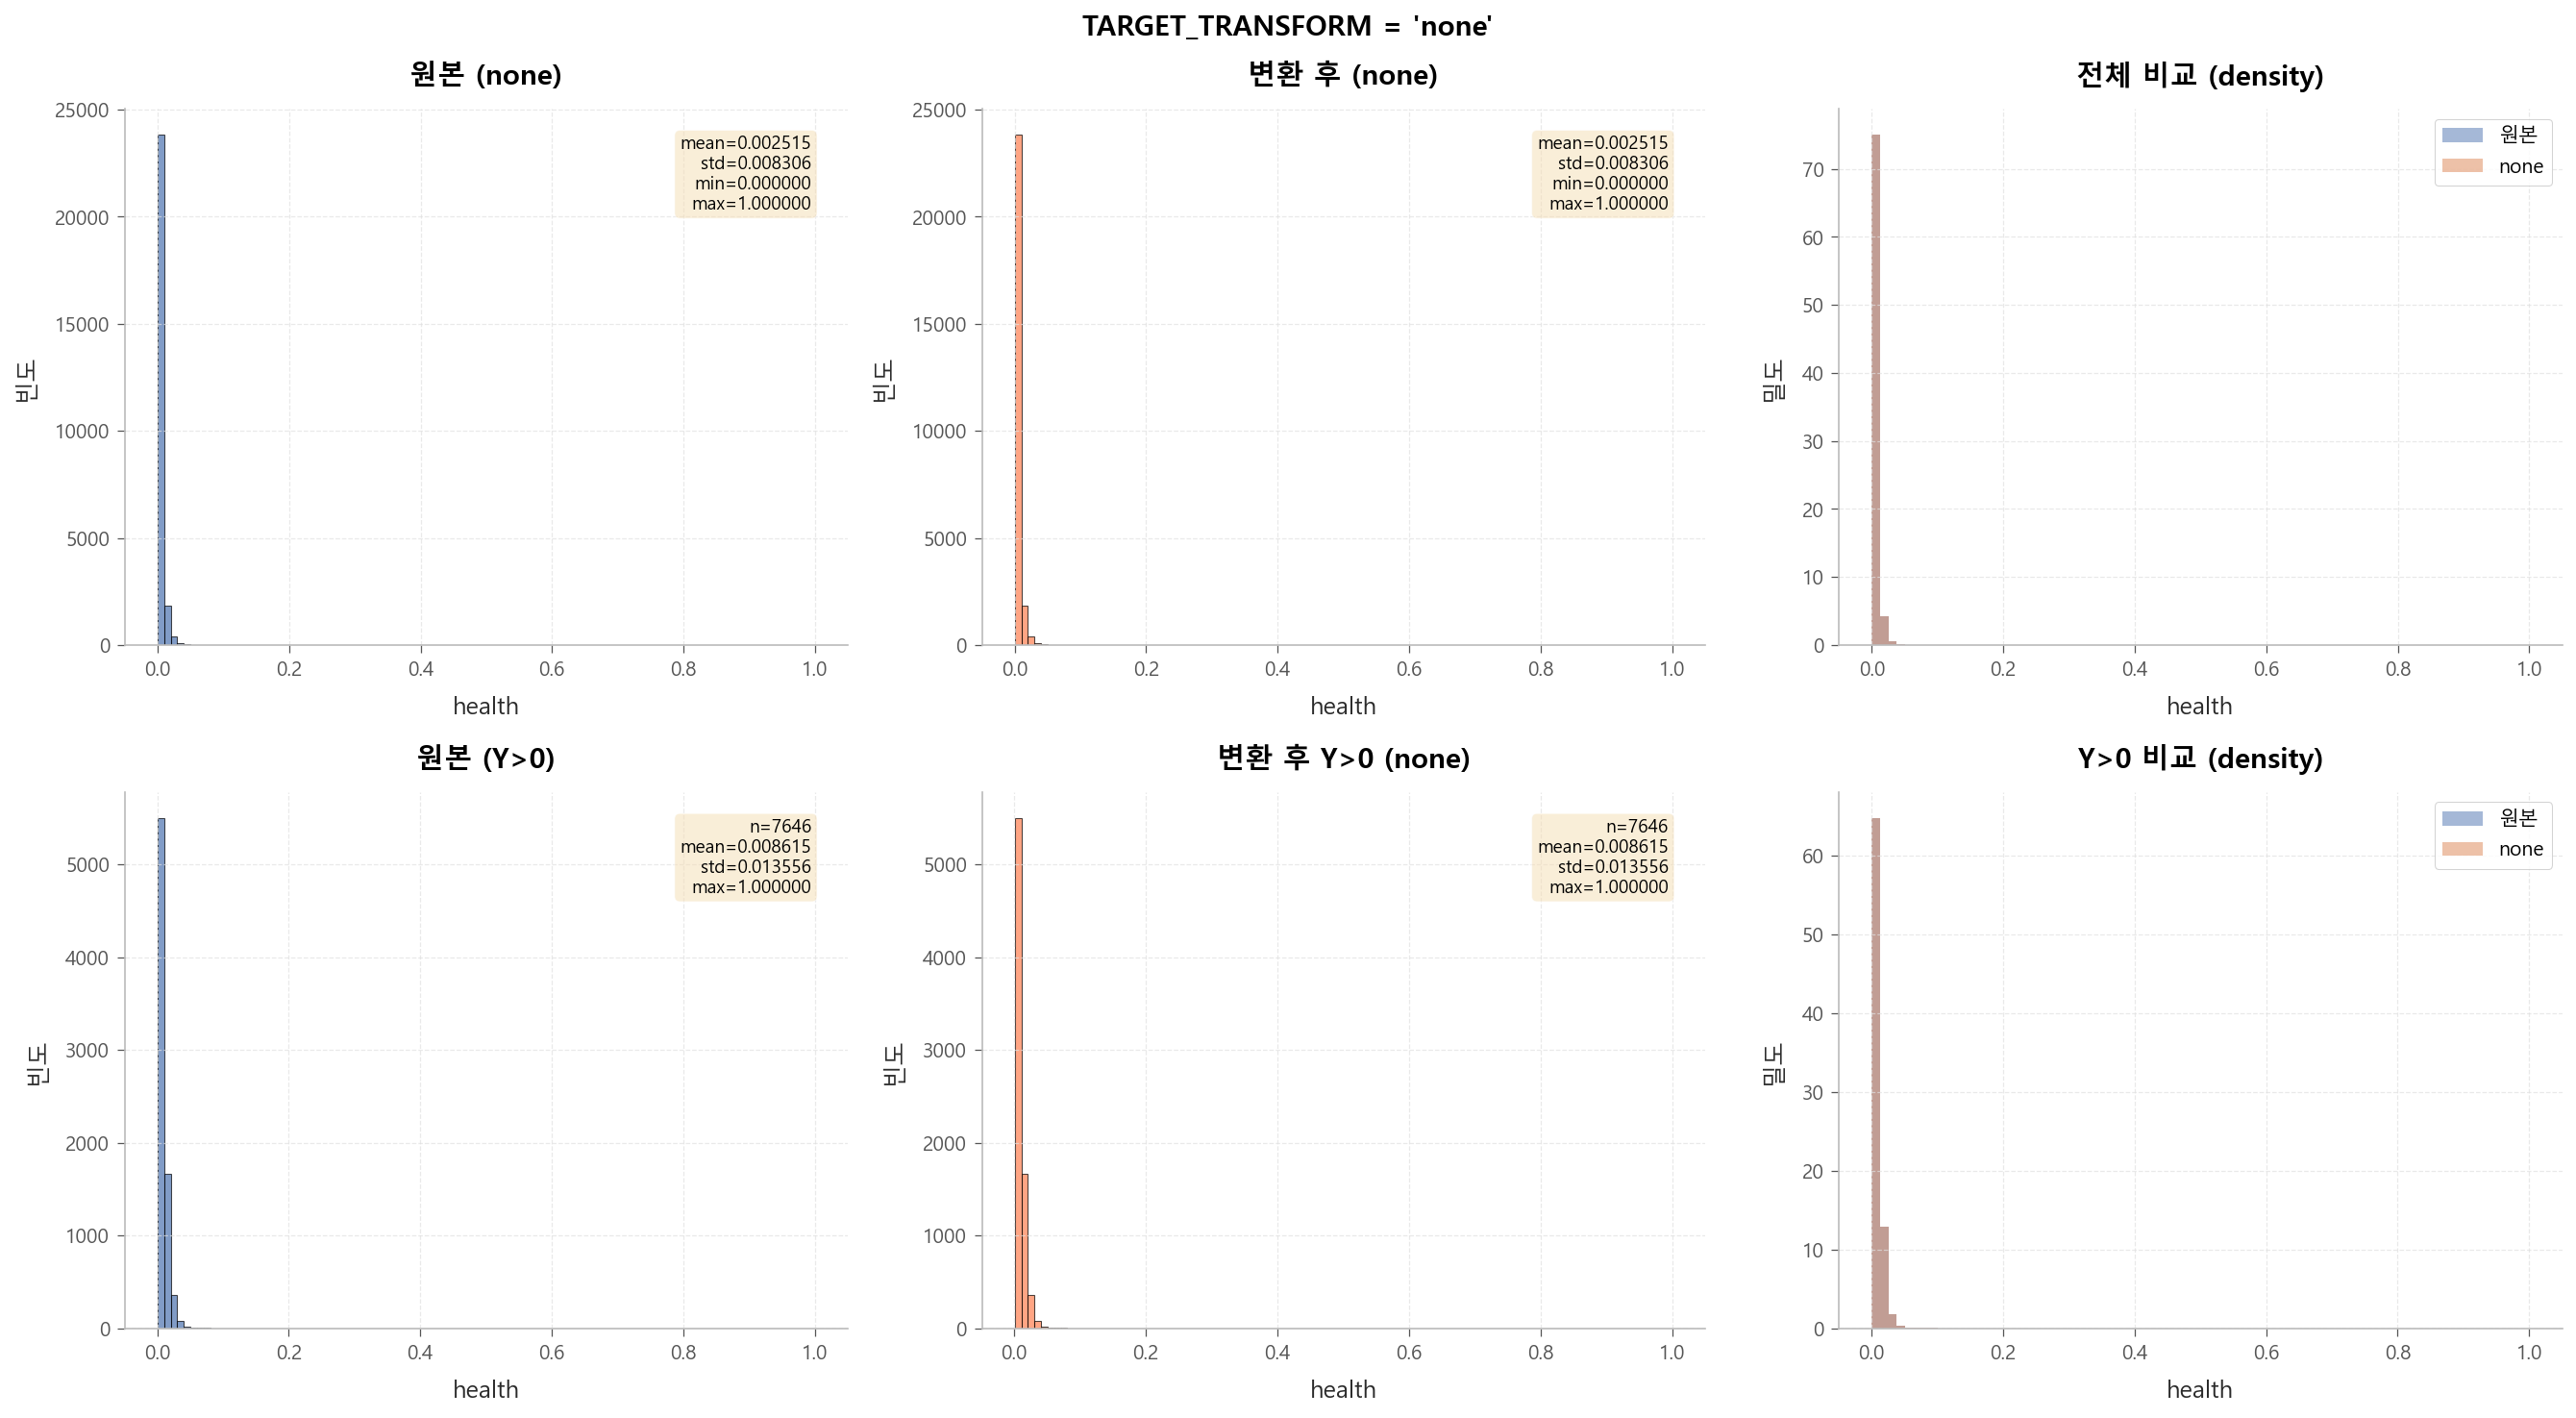

In [4]:
# 타깃 변환 (TARGET_TRANSFORM 스위치)
# 중요: ys_input 은 항상 **원본 스케일**을 유지한다 (train y만 CLIP_Y_EXTREME 적용).
# transform/inverse 는 e2e 함수 내부에서 reg fit 직전/예측 직후에만 일어나며,
# zero_clip/RMSE/val_rmse 등 모든 후처리는 원본 스케일에서 계산된다.
target_transformer = None
target_transform_fn = None
target_inverse_fn = None
ys_input = {k: v.copy() for k, v in ys.items()}

# y_train 극단값 클립 (CLIP_Y_EXTREME=True 시)
if CLIP_Y_EXTREME:
    _train_y_raw = ys_input['train'][TARGET_COL]
    _second_max = _train_y_raw[_train_y_raw < _train_y_raw.max()].max()
    ys_input['train'][TARGET_COL] = _train_y_raw.clip(upper=_second_max)
    print(f'[CLIP_Y_EXTREME] 1.0 → {_second_max:.6f} 클립 | '
          f'클립된 샘플: {(_train_y_raw >= 1.0).sum()}개')

if TARGET_TRANSFORM == 'log1p':
    target_transform_fn = lambda y: np.log1p(np.asarray(y))
    target_inverse_fn   = lambda y: np.clip(np.expm1(np.asarray(y)), 0.0, None)
    print('[log1p] target_transform_fn 등록 (ys_input 은 원본 유지)')

elif TARGET_TRANSFORM == 'yeo-johnson':
    from sklearn.preprocessing import PowerTransformer
    target_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    _train_y_clipped = ys_input['train'][TARGET_COL].values.reshape(-1, 1)
    target_transformer.fit(_train_y_clipped)
    _train_y_trans_vals = target_transformer.transform(_train_y_clipped).ravel()
    _tt_min = float(_train_y_trans_vals.min())
    _tt_max = float(_train_y_trans_vals.max())

    def target_transform_fn(y):
        return target_transformer.transform(np.asarray(y).reshape(-1, 1)).ravel()

    def target_inverse_fn(y):
        y_clip = np.clip(np.asarray(y), _tt_min, _tt_max)
        out = target_transformer.inverse_transform(y_clip.reshape(-1, 1)).ravel()
        out = np.clip(out, 0.0, None)
        return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

    print(f'[yeo-johnson] target_transform_fn 등록 '
          f'(train y 변환 범위: [{_tt_min:.6f}, {_tt_max:.6f}])')

else:  # 'none'
    print('[none] target 변환 없음')

# 타깃 변환 전후 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

y_orig = ys['train'][TARGET_COL]
# ys_input['train'] 은 이제 원본 스케일이므로, 시각화용으로만 on-the-fly 변환
if target_transform_fn is not None:
    y_trans = pd.Series(
        target_transform_fn(ys_input['train'][TARGET_COL].values),
        index=ys_input['train'].index,
    )
else:
    y_trans = ys_input['train'][TARGET_COL]
y_orig_nz = y_orig[y_orig > 0]
y_trans_nz = y_trans[y_trans != y_trans.min()]

# 1행: 전체
axes[0, 0].hist(y_orig, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('원본 (none)')
axes[0, 0].text(0.95, 0.95, f'mean={y_orig.mean():.6f}\nstd={y_orig.std():.6f}\nmin={y_orig.min():.6f}\nmax={y_orig.max():.6f}',
                transform=axes[0, 0].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0, 1].hist(y_trans, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title(f'변환 후 ({TARGET_TRANSFORM})')
axes[0, 1].text(0.95, 0.95, f'mean={y_trans.mean():.6f}\nstd={y_trans.std():.6f}\nmin={y_trans.min():.6f}\nmax={y_trans.max():.6f}',
                transform=axes[0, 1].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0, 2].hist(y_orig, bins=80, alpha=0.5, label='원본', density=True)
axes[0, 2].hist(y_trans, bins=80, alpha=0.5, label=f'{TARGET_TRANSFORM}', density=True)
axes[0, 2].set_title('전체 비교 (density)')
axes[0, 2].legend()

# 2행: Y>0만
axes[1, 0].hist(y_orig_nz, bins=100, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('원본 (Y>0)')
axes[1, 0].text(0.95, 0.95, f'n={len(y_orig_nz)}\nmean={y_orig_nz.mean():.6f}\nstd={y_orig_nz.std():.6f}\nmax={y_orig_nz.max():.6f}',
                transform=axes[1, 0].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1, 1].hist(y_trans_nz, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title(f'변환 후 Y>0 ({TARGET_TRANSFORM})')
axes[1, 1].text(0.95, 0.95, f'n={len(y_trans_nz)}\nmean={y_trans_nz.mean():.6f}\nstd={y_trans_nz.std():.6f}\nmax={y_trans_nz.max():.6f}',
                transform=axes[1, 1].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1, 2].hist(y_orig_nz, bins=80, alpha=0.5, label='원본', density=True)
axes[1, 2].hist(y_trans_nz, bins=80, alpha=0.5, label=f'{TARGET_TRANSFORM}', density=True)
axes[1, 2].set_title('Y>0 비교 (density)')
axes[1, 2].legend()

for ax in axes.flat:
    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel('빈도' if ax in axes[:, :2].flat else '밀도')

fig.suptitle(f'TARGET_TRANSFORM = {TARGET_TRANSFORM!r}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. E2E Optuna HPO 실행

1 Trial = 전처리 → CLF OOF → die→unit 집계 → FS → REG OOF → **OOF RMSE** (val-blind)

In [5]:
# Optuna sampler: multivariate TPE + group decomposition (교호작용 학습)
# - multivariate=True: 파라미터 joint dist 학습 → 좋은 조합을 같이 학습
# - group=True: conditional search space (parent OFF면 child suggest skip)와 함께 효과 극대화
# - n_startup_trials: TPE 학습 전 random startup. n_trials >> startup이어야 의미 있음
# 권장: n_trials >= 100, n_startup ~ 30~50
import optuna
OPTUNA_SAMPLER = optuna.samplers.TPESampler(
    multivariate=True,
    group=True,
    n_startup_trials=30,
)
print(f'Sampler: {type(OPTUNA_SAMPLER).__name__}  multivariate=True  group=True  n_startup_trials=30')
print(f'※ n_trials({e2e_params["n_trials"]})는 n_startup_trials보다 충분히 커야 TPE가 학습합니다 (권장 100+)')

# 매 trial마다 OOF + val + 보조 metric 한 줄 출력
def _trial_logger(study_, trial):
    if trial.state.name != 'COMPLETE':
        return
    oof = trial.value if trial.value is not None else float('nan')
    a = trial.user_attrs
    parts = [f'[T{trial.number:>3}] OOF={oof:.6f}']
    for key, label in [
        ('val_rmse',         'val'),
        ('val_skill',        'skill'),
        ('val_corr',         'corr'),
        ('val_rmse_ypos',    'ypos'),
        ('val_rmse_q90plus', 'q90+'),
        ('val_rmse_trim99',  'trim99'),
    ]:
        v = a.get(key)
        if v is not None:
            parts.append(f'{label}={v:.6f}' if 'corr' not in label and 'skill' not in label
                         else f'{label}={v:+.4f}')
    print('  '.join(parts))

#

# study.user_attrs에 저장할 메타데이터 패키징
study_user_attrs = {
    'exp_id': EXP_ID,
    'exp_type': EXP_TYPE,
    'memo': EXP_MEMO,
    'user': USER,
    'pipeline_config': pipeline_config,
    'e2e_params': e2e_params,
    'rerun_params': rerun_params,
    'sampling_params': sampling_params,
    'label_col': LABEL_COL,
    'exclude_cols': EXCLUDE_COLS,
    'target_transform': TARGET_TRANSFORM,
    'clip_y_extreme': CLIP_Y_EXTREME,
    'sampler': str(OPTUNA_SAMPLER),
    'preprocessing_search_space': {
        'PP_CLEAN_CANDIDATES':         {k: list(v) for k, v in PP_CLEAN_CANDIDATES.items()},
        'PP_OUTLIER_CANDIDATES':       {k: list(v) for k, v in PP_OUTLIER_CANDIDATES.items()},
        'PP_BINARIZE_CANDIDATES':      {k: list(v) for k, v in PP_BINARIZE_CANDIDATES.items()},
        'PP_ISO_ANOMALY_CANDIDATES':   {k: list(v) for k, v in PP_ISO_ANOMALY_CANDIDATES.items()},
        'PP_LDS_CANDIDATES':           {k: list(v) for k, v in PP_LDS_CANDIDATES.items()},
        'GROUP_ENCODER_CANDIDATES':    {k: list(v) for k, v in GROUP_ENCODER_CANDIDATES.items()},
        'AGG_PRESETS':                 [list(p) for p in AGG_PRESETS],
    },
}

result = run_e2e_optimization_with_pp(
    xs=xs,
    xs_dict=xs_dict,
    ys=ys_input,
    feat_cols=feat_cols,
    pipeline_config=pipeline_config,
    label_col=LABEL_COL,
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    sampler=OPTUNA_SAMPLER,
    **e2e_params,
    # 타깃 변환/역변환 (TARGET_TRANSFORM != 'none' 일 때만 유효)
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
    # SQLite / warm start
    exp_id=EXP_ID,
    db_path=DB_PATH,
    study_user_attrs=study_user_attrs,
    warm_start_top_k=30,
    warm_start_enabled=True,
    trial_callbacks=[_trial_logger],   # 매 trial OOF+val+보조 metric 출력
)

study = result['study']
best_params = result['best_params']

print(f'\n── Best Trial ──')
print(f'OOF RMSE (Optuna objective): {result["best_value"]:.6f}')

Sampler: TPESampler  multivariate=True  group=True  n_startup_trials=30
※ n_trials(100)는 n_startup_trials보다 충분히 커야 TPE가 학습합니다 (권장 100+)


  0%|          | 0/100 [00:00<?, ?it/s]

[T  0] OOF=0.008576  val=0.006028  skill=+0.0480  corr=+0.0824  ypos=0.009085  q90+=0.015175  trim99=0.004906
[T  1] OOF=0.009213  val=0.006646  skill=-0.0495  corr=+0.0753  ypos=0.008464  q90+=0.013978  trim99=0.005731
[T  2] OOF=0.009241  val=0.006660  skill=-0.0517  corr=+0.0691  ypos=0.008475  q90+=0.013959  trim99=0.005751
[T  3] OOF=0.009357  val=0.006789  skill=-0.0721  corr=+0.0955  ypos=0.008355  q90+=0.013705  trim99=0.005918
[T  4] OOF=0.008821  val=0.006288  skill=+0.0070  corr=+0.0999  ypos=0.008725  q90+=0.014531  trim99=0.005267
[T  5] OOF=0.009986  val=0.007327  skill=-0.1570  corr=+0.0547  ypos=0.008197  q90+=0.013135  trim99=0.006567
[T  6] OOF=0.010046  val=0.007381  skill=-0.1655  corr=+0.0718  ypos=0.008149  q90+=0.013011  trim99=0.006636
[T  7] OOF=0.009232  val=0.006639  skill=-0.0484  corr=+0.0838  ypos=0.008463  q90+=0.013947  trim99=0.005728
[T  8] OOF=0.008826  val=0.006291  skill=+0.0066  corr=+0.0968  ypos=0.008722  q90+=0.014522  trim99=0.005271
[T  9] OOF

## 5. Best Trial 재실행 (더 많은 Fold)

HPO에서 찾은 best preprocessing + best HP로 더 안정적인 예측을 생성한다.

In [ ]:
final = rerun_best_trial_with_pp(
    xs=xs,
    xs_dict=xs_dict,
    ys=ys_input,
    feat_cols=feat_cols,
    best_params=best_params,
    # conditional sampling으로 skip된 단일-후보 키들도 보존하여 HPO와 동일 전처리 보장
    best_pp_params_resolved=study.best_trial.user_attrs.get('resolved_pp_params'),
    pipeline_config=pipeline_config,
    clf_model=e2e_params['clf_model'],
    reg_model=e2e_params['reg_model'],
    label_col=LABEL_COL,
    imbalance_method=e2e_params['imbalance_method'],
    top_k_fixed=e2e_params['top_k_fixed'],
    clf_filter_threshold_fixed=e2e_params['clf_filter_threshold_fixed'],
    zero_clip_threshold_fixed=e2e_params['zero_clip_threshold_fixed'],
    clf_fixed=e2e_params['clf_fixed'],
    reg_fixed=e2e_params['reg_fixed'],
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    **rerun_params,
)

# 주의: rerun_best_trial_with_pp 내부에서 reg 예측 직후 이미 역변환 완료.
# final['val_pred'] / final['test_pred'] / final['oof_pred'] 는 모두 **원본 스케일**이다.

# --- OOF 평가 (핵심 지표) ---
# 정답은 원본 ys에서 직접 가져옴 (클립 전 y 포함)
if rerun_params['mode'] == 'kfold' and 'oof_pred' in final:
    y_train_unit = ys['train'][TARGET_COL].values
    if sampling_params['use_sampling']:
        # 샘플링 시 unit_data에 있는 unit만 매칭
        train_keys = final['unit_data']['train'][KEY_COL].values
        y_train_raw = ys['train'].set_index(KEY_COL).loc[train_keys, TARGET_COL].values
        y_train_unit = y_train_raw
    rerun_oof_rmse = rmse(y_train_unit, final['oof_pred'])
    evaluate(y_train_unit, final['oof_pred'], label='E2E Rerun (OOF)')
    final['oof_rmse'] = float(rerun_oof_rmse)
else:
    rerun_oof_rmse = None

# --- Validation 평가 (EVAL_VAL=True 일 때만 참고용) ---
if EVAL_VAL:
    y_val = ys['validation'][TARGET_COL].values
    evaluate(y_val, final['val_pred'], label='E2E Rerun (val, 참고)')
    final['val_rmse'] = float(rmse(y_val, final['val_pred']))
else:
    print('[val] EVAL_VAL=False → val RMSE 계산 생략')
    final['val_rmse'] = None

# --- Test 평가 (EVAL_TEST=True 일 때만 최종 RMSE 계산) ---
if EVAL_TEST:
    y_test = ys['test'][TARGET_COL].values
    test_rmse_score = rmse(y_test, final['test_pred'])
    evaluate(y_test, final['test_pred'], label='E2E Rerun (test)')
else:
    test_rmse_score = None
    print('[test] EVAL_TEST=False → test RMSE 계산 생략 (test peeking 방지)')

In [7]:
#
# RMSE 비교표 : HPO vs Rerun × OOF / Val(참고) / Test
#
# - OOF : K-fold OOF 예측 기반 RMSE (Optuna 최적화 기준)
# - Val : EVAL_VAL=True일 때만 참고용으로 표시
# - Test : EVAL_TEST=True일 때만 표시 (test peeking 방지)

# HPO best trial
hpo_best     = study.best_trial
hpo_oof      = hpo_best.value  # OOF RMSE (Optuna 최적화 기준)
hpo_val_ref  = hpo_best.user_attrs.get('val_rmse', None)
hpo_n_folds  = e2e_params['n_folds']

# Rerun
rerun_oof  = final.get('oof_rmse', rerun_oof_rmse)
rerun_val  = final.get('val_rmse')
rerun_test = test_rmse_score  # None if EVAL_TEST=False

def _fmt(v, na='—'):
    return f'{v:.6f}' if v is not None else na

hpo_test_str    = '—'
rerun_test_str  = _fmt(rerun_test, 'N/A (EVAL_TEST=False)')
rerun_oof_str   = _fmt(rerun_oof, 'N/A (mode=single)')
rerun_val_str   = _fmt(rerun_val, 'N/A (EVAL_VAL=False)')

hpo_label = f'HPO   ({hpo_n_folds}-fold)'
if rerun_params['mode'] == 'kfold':
    rerun_label = f'Rerun ({rerun_params["n_folds"]}-fold)'
else:
    rerun_label = f'Rerun (single, es_holdout={rerun_params["es_holdout"]})'

# 표 출력
LINE = '=' * 78
print(LINE)
print('RMSE 비교표  (Optuna 최적화 기준: OOF RMSE)')
print(LINE)
print(f'{"":22s}  {"OOF":>12s}  {"Val(참고)":>12s}  {"Test":>24s}')
print('-' * 78)
print(f'{hpo_label:22s}  {_fmt(hpo_oof):>12s}  {_fmt(hpo_val_ref):>12s}  {hpo_test_str:>24s}')
print(f'{rerun_label:22s}  {rerun_oof_str:>12s}  {rerun_val_str:>12s}  {rerun_test_str:>24s}')
print(LINE)
print(' ※ OOF = K-fold Out-of-Fold 예측 기반 RMSE (Optuna 최적화 기준)')
print(' ※ Val / Test = K-fold 앙상블 예측 RMSE (참고용, 비공개 데이터)')

RMSE 비교표  (Optuna 최적화 기준: OOF RMSE)
                                 OOF       Val(참고)                      Test
------------------------------------------------------------------------------
HPO   (3-fold)              0.008561      0.006027                         —
Rerun (5-fold)              0.008646      0.006160                  0.008708
 ※ OOF = K-fold Out-of-Fold 예측 기반 RMSE (Optuna 최적화 기준)
 ※ Val / Test = K-fold 앙상블 예측 RMSE (참고용, 비공개 데이터)


## 6. 결과 시각화

In [8]:
# Optuna 결과 시각화
from modules.viz import plot_optuna_results
import optuna.visualization as ov

# (1) history + param importance + slice plot — 기존 viz 모듈
plot_optuna_results(study, title_prefix="PP-test -- ")

# (2) Parallel Coordinate — 모든 trial을 평행축 사이 선으로 (신경망 모양)
#     좋은 RMSE 영역으로 선들이 어떻게 수렴하는지 한눈에 보임
fig_pc = ov.plot_parallel_coordinate(study)
fig_pc.update_layout(title="PP-test -- Parallel Coordinate (전체 trials)")
fig_pc.show()

# (3) (선택) Contour — 두 파라미터 평면에서 RMSE 등고선
#     상위 2개 중요 파라미터만 자동 선택됨. 파라미터가 너무 많으면 느려서 try/except로 스킵
try:
    fig_ct = ov.plot_contour(study)
    fig_ct.update_layout(title="PP-test -- Contour")
    fig_ct.show()
except Exception as e:
    print(f"[contour skipped] {e}")


[W 2026-04-28 16:09:25,287] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,288] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,289] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,290] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,292] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,293] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,297] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,299] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,301] Param pp_agg_preset_idx unique value length is less than 2.
[W 2026-04-28 16:09:25,303] Param pp_agg_preset_idx unique value length is less than 2.


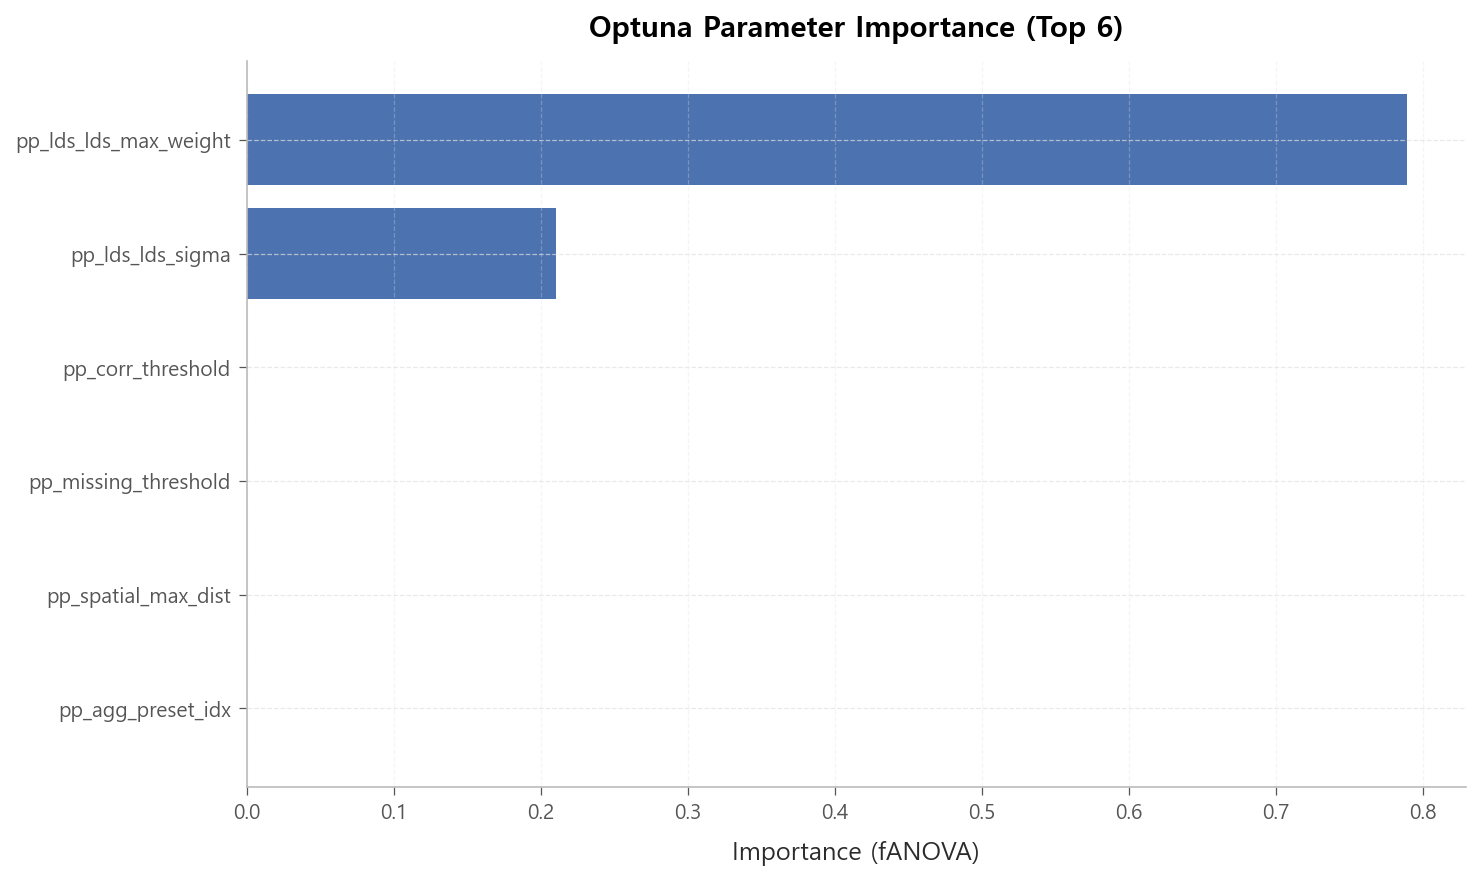


파라미터 중요도 (fANOVA):
  pp_lds_lds_max_weight                    0.7893
  pp_lds_lds_sigma                         0.2102
  pp_corr_threshold                        0.0003
  pp_missing_threshold                     0.0002
  pp_spatial_max_dist                      0.0000
  pp_agg_preset_idx                        0.0000


In [9]:
#
# Optuna 파라미터 중요도 (fANOVA)
#
from optuna.importance import get_param_importances, FanovaImportanceEvaluator

param_imp = get_param_importances(
    study,
    evaluator=FanovaImportanceEvaluator(seed=SEED),
)

# 상위 20개 파라미터
top_params = dict(list(param_imp.items())[:20])

fig, ax = plt.subplots(figsize=(10, 6))
names = list(top_params.keys())[::-1]
values = list(top_params.values())[::-1]
ax.barh(names, values)
ax.set_xlabel("Importance (fANOVA)")
ax.set_title(f"Optuna Parameter Importance (Top {len(top_params)})")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\n파라미터 중요도 (fANOVA):")
for k, v in top_params.items():
    print(f"  {k:40s} {v:.4f}")

## 6.5 Trial별 보조 metric 비교

단일 OOF RMSE로는 보이지 않는 trial 간 차이를 다축으로 비교한다.
- **val_skill** = 1 - val_rmse / predict-zero baseline (split 분포 정규화)
- **val_corr** = Pearson(y, pred), 단조성/순위 학습 여부
- **val_rmse_ypos** = Y>0 서브셋 RMSE, Stage 2 회귀 신호 분리
- **val_rmse_q90plus** = Y > q90 tail RMSE, 큰 y 학습력
- **val_rmse_trim99** = Y < q99 trimmed RMSE, 극단값 1~2개 영향 제거

OOF RMSE로 정렬한 best와, 다른 metric으로 정렬한 best가 다르면 → objective 재검토 시그널.


완료 trial: 100, 보조 metric 비결측: 100

── Top 5 by OOF RMSE (asc) ──
 trial  oof_rmse  val_rmse  val_skill  val_corr  val_ypos  val_q90+  val_trim99
    51  0.008561  0.006027   0.048184  0.101299  0.009056  0.015132    0.004904
    40  0.008561  0.006027   0.048184  0.101299  0.009056  0.015132    0.004904
    42  0.008561  0.006027   0.048184  0.101299  0.009056  0.015132    0.004904
    41  0.008561  0.006027   0.048184  0.101299  0.009056  0.015132    0.004904
    61  0.008561  0.006027   0.048184  0.101299  0.009056  0.015132    0.004904

── Top 5 by Val RMSE (asc) ──
 trial  oof_rmse  val_rmse  val_skill  val_corr  val_ypos  val_q90+  val_trim99
    49  0.008561  0.006022   0.049076  0.108540  0.009055  0.015133    0.004898
    99  0.008561  0.006022   0.049076  0.108540  0.009055  0.015133    0.004898
    65  0.008574  0.006023   0.048885  0.088481  0.009076  0.015160    0.004902
    55  0.008574  0.006023   0.048885  0.088481  0.009076  0.015160    0.004902
    85  0.008565  0.0060

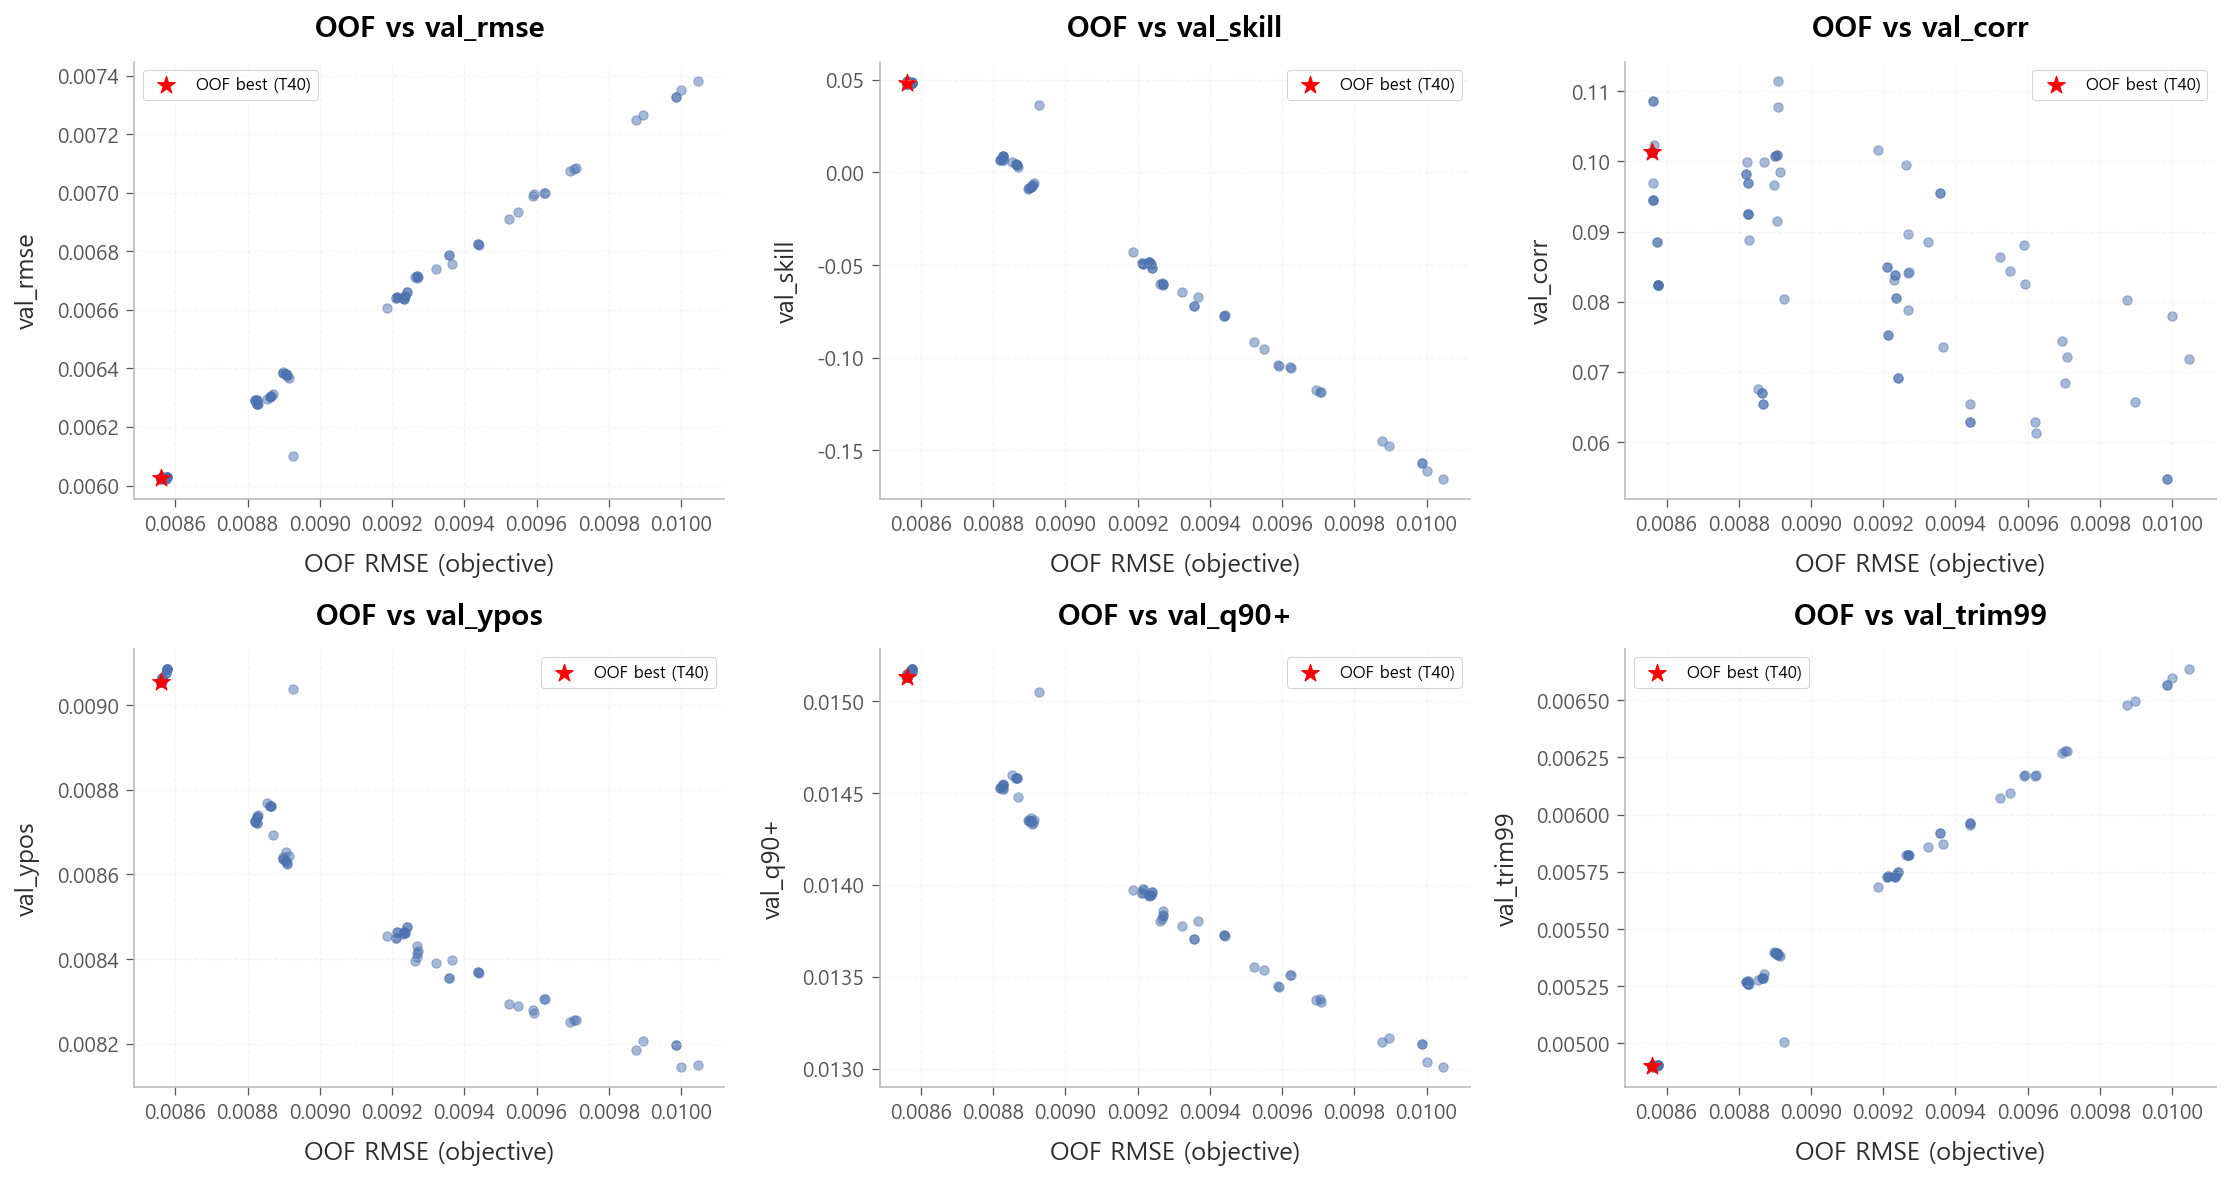

In [10]:
#
# Trial별 보조 metric 비교표 + 산점도
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# study에서 trial별 보조 metric 수집
_rows = []
for t in study.trials:
    if t.state.name != 'COMPLETE':
        continue
    a = t.user_attrs
    _rows.append({
        'trial':       t.number,
        'oof_rmse':    t.value,
        'val_rmse':    a.get('val_rmse'),
        'val_skill':   a.get('val_skill'),
        'val_corr':    a.get('val_corr'),
        'val_ypos':    a.get('val_rmse_ypos'),
        'val_q90+':    a.get('val_rmse_q90plus'),
        'val_trim99':  a.get('val_rmse_trim99'),
    })
df_diag = pd.DataFrame(_rows)
print(f'완료 trial: {len(df_diag)}, 보조 metric 비결측: {df_diag["val_skill"].notna().sum()}')

# metric별 best 5 trial 비교
rank_metrics = [
    ('oof_rmse',   'asc',  'OOF RMSE'),
    ('val_rmse',   'asc',  'Val RMSE'),
    ('val_skill',  'desc', 'Val skill (높을수록 좋음)'),
    ('val_corr',   'desc', 'Val corr (높을수록 좋음)'),
    ('val_ypos',   'asc',  'Val Y>0 RMSE'),
    ('val_q90+',   'asc',  'Val Y>q90 RMSE'),
    ('val_trim99', 'asc',  'Val trimmed99 RMSE'),
]
_show_cols = ['trial', 'oof_rmse', 'val_rmse', 'val_skill', 'val_corr', 'val_ypos', 'val_q90+', 'val_trim99']
for col, direction, label in rank_metrics:
    if col not in df_diag or df_diag[col].isna().all():
        continue
    asc = (direction == 'asc')
    top = df_diag.sort_values(col, ascending=asc).head(5)
    print()
    print(f'── Top 5 by {label} ({direction}) ──')
    print(top[_show_cols].to_string(index=False))

# metric 간 상관
_num = df_diag.select_dtypes(include=[np.number]).drop(columns=['trial'], errors='ignore')
if len(_num.dropna()) >= 5:
    print()
    print('── Trial 간 metric 상관 (Pearson) ──')
    print(_num.corr().round(3).to_string())

# 산점도: oof_rmse vs 보조 metric
_metrics_to_plot = [m for m in ['val_rmse', 'val_skill', 'val_corr', 'val_ypos', 'val_q90+', 'val_trim99']
                    if m in df_diag and df_diag[m].notna().sum() >= 5]
if _metrics_to_plot:
    n = len(_metrics_to_plot)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axes = np.array(axes).flatten()
    best_idx = df_diag['oof_rmse'].idxmin()
    best_t = int(df_diag.loc[best_idx, 'trial'])
    best_oof = float(df_diag.loc[best_idx, 'oof_rmse'])
    for ax, m in zip(axes, _metrics_to_plot):
        ax.scatter(df_diag['oof_rmse'], df_diag[m], alpha=0.5, s=20)
        best_y = float(df_diag.loc[best_idx, m])
        ax.scatter(best_oof, best_y, color='red', s=80, marker='*',
                   label=f'OOF best (T{best_t})')
        ax.set_xlabel('OOF RMSE (objective)')
        ax.set_ylabel(m)
        ax.set_title(f'OOF vs {m}')
        ax.legend(loc='best', fontsize=8)
        ax.grid(alpha=0.3)
    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

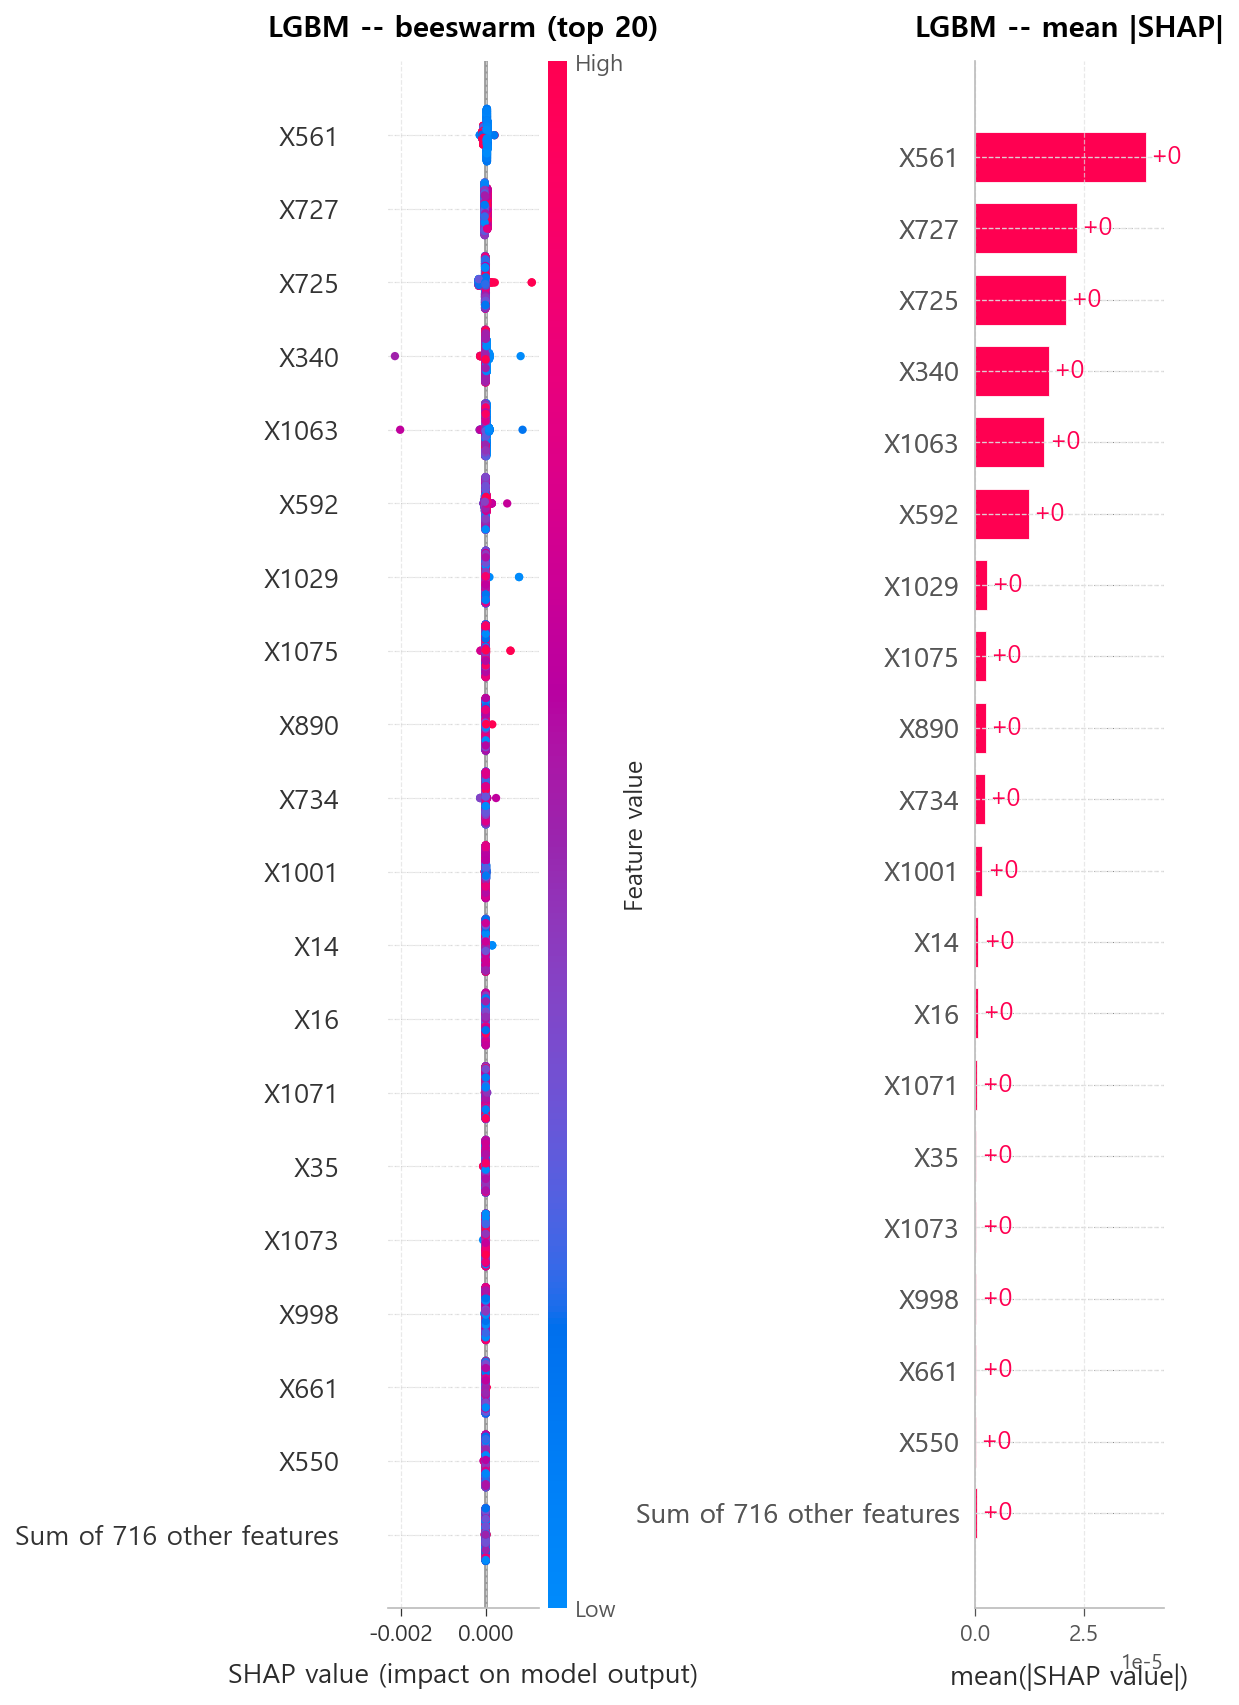

In [11]:
# SHAP 분석 -- reg 모델
from modules.viz import plot_shap_analysis

selected_cols = final["selected_cols"]

# reg_level='position'에서는 rerun 내부에서 final['unit_data']['val']이
# 집계된 (KEY_COL, TARGET_COL) 2컬럼 DataFrame으로 덮어쓰인다.
# die-level feature는 'unit_data_die'에 집계 전 concat 형태로 보관됨.
# 'unit' 모드면 unit_data에 feature가 그대로 있으므로 폴백.
feat_source = final.get("unit_data_die") or final["unit_data"]
X_val_arr = feat_source["val"][selected_cols].values

fold_models = final.get("reg_models", [])
if fold_models:
    plot_shap_analysis(
        [fold_models[0]],
        X_val_arr, selected_cols,
        model_names=["LGBM"],
    )
else:
    print("fold_models not available for SHAP")

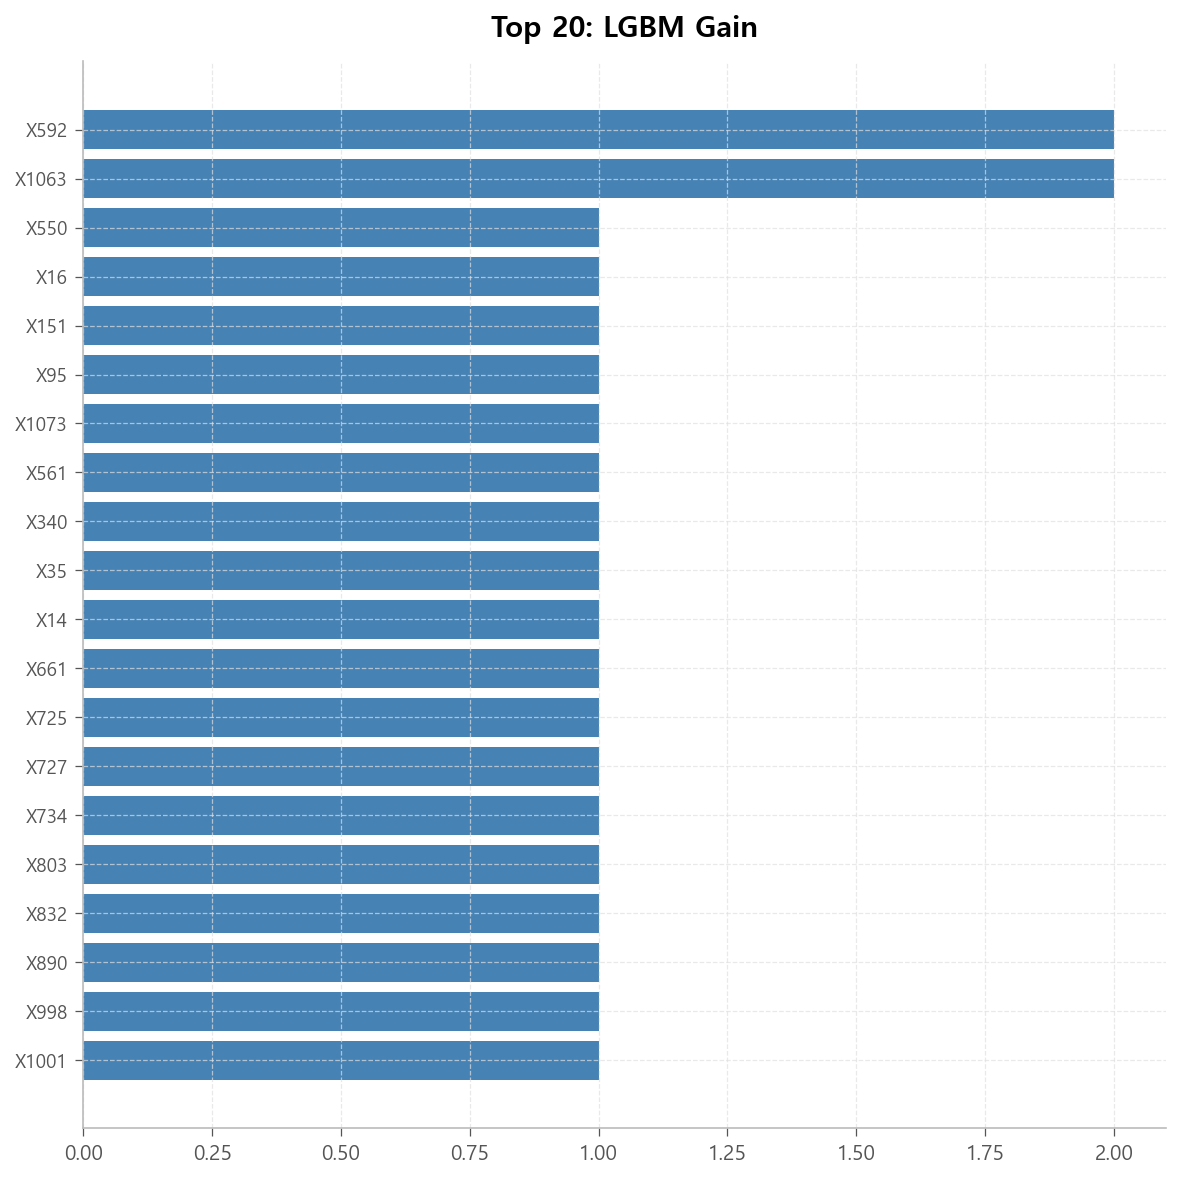

In [12]:
# Feature Importance -- LGBM gain + permutation
from modules.viz import plot_fi_comparison

# gain
fold_models = final.get('reg_models') or final.get('per_model_fold_models', {}).get('lgbm', [])
if fold_models and hasattr(fold_models[0], 'feature_importances_'):
    selected_cols = final['selected_cols']
    gain = fold_models[0].feature_importances_
    df_imp = pd.DataFrame({'feature': selected_cols, 'lgbm_gain': gain})
    df_imp = df_imp.sort_values('lgbm_gain', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 8))
    top = df_imp.head(20)
    ax.barh(range(20), top['lgbm_gain'].values, color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top['feature'].values, fontsize=9)
    ax.set_title('Top 20: LGBM Gain')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('fold_models not available for FI')


## 7. 최종 CSV 출력 + Study 저장

- `{EXP_ID}_final_val.csv` / `{EXP_ID}_final_test.csv` — 베스트 trial 예측
- `{EXP_ID}_study.pkl` — trial별 파라미터·val RMSE·user_attrs 전부 (사후 분석용)

In [13]:
import pickle

#
# 1) Single E2E (rerun 결과) 메트릭/예측 준비
#
single_oof_rmse  = final.get('oof_rmse')
single_val_rmse  = final.get('val_rmse')
single_test_rmse = float(test_rmse_score) if test_rmse_score is not None else None
single_val_pred  = final['val_pred']
single_test_pred = final['test_pred']
single_key_val   = final['unit_data']['val'][KEY_COL].values
single_key_test  = final['unit_data']['test'][KEY_COL].values

def _fmt_rmse(v, na='N/A'):
    return f'{v:.6f}' if v is not None else na

print(f'★ FINAL: e2e_single (lgbm, preprocessing HPO)')
print(f'  OOF RMSE : {_fmt_rmse(single_oof_rmse)}  (최적화 기준)')
print(f'  Val RMSE : {_fmt_rmse(single_val_rmse, "N/A (EVAL_VAL=False)")}  (참고)')
print(f'  Test RMSE: {_fmt_rmse(single_test_rmse, "N/A (EVAL_TEST=False)")}')

#
# 2) CSV + Optuna study pickle 저장 (SAVE_OUTPUTS 스위치)
#
if SAVE_OUTPUTS:
    final_val_path  = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'{EXP_ID}_final_val.csv')
    final_test_path = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'{EXP_ID}_final_test.csv')
    pd.DataFrame({KEY_COL: single_key_val,  TARGET_COL: single_val_pred }).to_csv(final_val_path,  index=False)
    pd.DataFrame({KEY_COL: single_key_test, TARGET_COL: single_test_pred}).to_csv(final_test_path, index=False)
    print(f'  → {final_val_path}')
    print(f'  → {final_test_path}')

    study_path = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'{EXP_ID}_study.pkl')
    with open(study_path, 'wb') as f:
        pickle.dump(study, f)
    print(f'  → {study_path}  ({len(study.trials)} trials)')
else:
    print('  [SAVE_OUTPUTS=False] CSV / study pickle 저장 생략')

★ FINAL: e2e_single (lgbm, preprocessing HPO)
  OOF RMSE : 0.008646  (최적화 기준)
  Val RMSE : 0.006160  (참고)
  Test RMSE: 0.008708
  [SAVE_OUTPUTS=False] CSV / study pickle 저장 생략


## 8. 실험 로그

In [14]:
#
# 실험 로그 — CSV 기록 + SQLite user_attrs 업데이트
#
# 재현성 원칙: SQLite(optuna_{USER}.db)에 모든 trial + 메타데이터가 저장됨
# CSV는 팀 공용 성적표 (실험 단위 요약, 로컬만 기록 — Drive 업로드 비활성화)

# CSV 기록 (로컬만, Drive 업로드 OFF → Drive 승인 팝업 방지)
log_experiment(
    csv_path=EXP_CSV_PATH,
    exp_id=EXP_ID,
    exp_type=EXP_TYPE,
    best_model=f'e2e_single ({e2e_params["reg_model"]})',
    val_rmse=single_val_rmse,
    test_rmse=single_test_rmse,
    n_features=len(final['selected_cols']),
    memo=EXP_MEMO,
    user=USER,
    n_trials=len(study.trials),
)

# Rerun 최종 결과를 study.user_attrs에 추가 기록 (SQLite에 즉시 반영)
study.set_user_attr('final_method', 'e2e_single')
study.set_user_attr('final_oof_rmse', single_oof_rmse)
study.set_user_attr('final_val_rmse', single_val_rmse)
study.set_user_attr('final_test_rmse', single_test_rmse)
study.set_user_attr('final_best_trial_number', study.best_trial.number)
study.set_user_attr('final_selected_cols', final['selected_cols'])

# .db 최종 로컬 PC 다운로드 (브라우저 다운로드, Drive 승인 불필요)
from utils.config import ENV
if ENV == 'colab':
    from google.colab import files
    db_size_mb = os.path.getsize(DB_PATH) / 1024 / 1024
    print(f'DB 다운로드 시작: {os.path.basename(DB_PATH)} ({db_size_mb:.1f} MB)')
    files.download(DB_PATH)
    print('DB → 로컬 PC 다운로드 요청 완료 (브라우저 기본 다운로드 폴더 확인)')

  주의: 기준 실험 'pp-test-001'이 없어 증감을 계산할 수 없습니다.

실험 기록 완료: pp-test-007
  타입: preprocessing search (model fixed) | 베스트: e2e_single (lgbm) | user: jh
  Val RMSE:  0.006160
  Test RMSE: 0.008708
  피처수: 735 | n_trials: 100 | 메모: LGBM 단독 + 모델 파라미터 고정(library default) + 전처리 search space 전체 open
  csv: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\preprocessing_test\experiments.csv
